In [1]:
import kagglehub
import pandas as pd
import os
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# Скачивание датасета
path = kagglehub.dataset_download("rabieelkharoua/predict-online-gaming-behavior-dataset")
file = os.listdir(path)
file_path = os.path.join(path, file[0])

data = pd.read_csv(file_path)
data.describe()


,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [3]:
data["EngagementLevel"].unique()

<ArrowStringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

Так как в уровне заинтересованности всего 3 возможных значения, можно обойтись без One-Hot Encoding и прочих инструментов и просто заменить на 0-2. Не будет проблем в том, что модель будет видеть между 0 и 2 большую разницу, чем, например, между 0 и 1, так как разниа между Low и High действительно больше, чем между Low и Medium. Аналогично и с уровнем сложности.

In [4]:
engagement_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['EngagementLevel'] = data['EngagementLevel'].map(engagement_mapping)

diff_mapping = {'Easy': 0, 'Medium': 1, 'Hard': 2}
data['GameDifficulty'] = data['GameDifficulty'].map(diff_mapping)

In [5]:
data

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,1,6,108,79,25,1
1,9001,29,Female,USA,Strategy,5.525961,0,1,5,144,11,10,1
2,9002,22,Female,USA,Sports,8.223755,0,0,16,142,35,41,2
3,9003,35,Male,USA,Action,5.265351,1,0,9,85,57,47,1
4,9004,33,Male,Europe,Action,15.531945,0,1,2,131,95,37,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,0,0,4,75,85,14,1
40030,49030,44,Female,Other,Simulation,13.539280,0,2,19,114,71,27,2
40031,49031,15,Female,USA,RPG,0.240057,1,0,10,176,29,1,2
40032,49032,34,Male,USA,Sports,14.017818,1,1,3,128,70,10,1


In [6]:
data["EngagementLevel"].value_counts()

EngagementLevel
1    19374
2    10336
0    10324
Name: count, dtype: int64

Большинство игроков находится на уровне Medium, что логично. Уровни Low и High имеют одинаковый объём.

*НУЖНО*
- Перевести текстовые атрибуты в числовые +
- Создать train/test +
- Использовать Scaler +
- Посмотреть уровень корреляции относительно главной метрики (если это возможно) +
- Обучить несколько моделей +
- Оценка качества (f1_score_macro) +
- Посмотреть самые сильные зависимости
- Проверить результаты
- Сделать выводы

Преобразуем категориальные признаки в числовые значения

In [7]:
data = pd.get_dummies(data, columns=["Location"], prefix="Location", dtype=int)
data = pd.get_dummies(data, columns=["GameGenre"], prefix="GameGenre", dtype=int)
data = pd.get_dummies(data, columns=["Gender"], prefix="Gender", dtype=int)

In [8]:
data

,PlayerID,Age,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,...,Location_Europe,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,Gender_Female,Gender_Male
0,9000,43,16.271119,0,1,6,108,79,25,1,...,0,1,0,0,0,0,0,1,0,1
1,9001,29,5.525961,0,1,5,144,11,10,1,...,0,0,1,0,0,0,0,1,1,0
2,9002,22,8.223755,0,0,16,142,35,41,2,...,0,0,1,0,0,0,1,0,1,0
3,9003,35,5.265351,1,0,9,85,57,47,1,...,0,0,1,1,0,0,0,0,0,1
4,9004,33,15.531945,0,1,2,131,95,37,1,...,1,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,20.619662,0,0,4,75,85,14,1,...,0,0,1,0,0,0,0,1,0,1
40030,49030,44,13.539280,0,2,19,114,71,27,2,...,0,1,0,0,0,1,0,0,1,0
40031,49031,15,0.240057,1,0,10,176,29,1,2,...,0,0,1,0,1,0,0,0,1,0
40032,49032,34,14.017818,1,1,3,128,70,10,1,...,0,0,1,0,0,0,1,0,0,1


Разделение train/test

In [9]:
X = data.drop(columns=["PlayerID", "EngagementLevel"])
y = data["EngagementLevel"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Масштабирование метрик

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
corr_matrix = data.corr()
corr_matrix["EngagementLevel"].sort_values(ascending=False)

EngagementLevel              1.000000
SessionsPerWeek              0.605996
AvgSessionDurationMinutes    0.476698
AchievementsUnlocked         0.060576
PlayerLevel                  0.059315
InGamePurchases              0.008209
GameGenre_Strategy           0.007700
Location_Asia                0.006110
GameDifficulty               0.005057
Gender_Female                0.004978
Location_USA                 0.002499
GameGenre_Simulation         0.001184
Age                          0.000824
GameGenre_Sports             0.000572
GameGenre_Action             0.000225
PlayTimeHours               -0.001849
PlayerID                    -0.001926
Location_Other              -0.003174
Gender_Male                 -0.004978
Location_Europe             -0.005965
GameGenre_RPG               -0.009707
Name: EngagementLevel, dtype: float64

*Создание и обучение моделей*

Логистическая регрессия

In [12]:
logistic_regressor = LogisticRegression()
logistic_regressor.fit(X_train_scaled, y_train)
prediction_lr = logistic_regressor.predict(X_test_scaled)
f1_macro_lr = f1_score(y_test, prediction_lr, average="macro")

Дерево решений

In [13]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
prediction_dt = decision_tree.predict(X_test)
f1_macro_dt = f1_score(y_test, prediction_dt, average="macro")

Случайный лес (сбалансированные веса)

In [35]:
rand_forest_class = RandomForestClassifier(class_weight="balanced", random_state=42)
rand_forest_class.fit(X_train, y_train)
prediction_rfc = rand_forest_class.predict(X_test)
f1_macro_rfc = f1_score(y_test, prediction_rfc, average="macro")

макро метрики качесва работы моделей

In [38]:
print(f"Логистическая регрессия: {f1_macro_lr}")
print(f"Дерево решений: {f1_macro_dt}")
print(f"случайное дерево: {f1_macro_rfc}")

Логистическая регрессия: 0.8142492601965876
Дерево решений: 0.8175692871202656
случайное дерево: 0.8993253069473979


Алгоритм случайного леса показывает лучшие результаты (+8.8% в сравнении с логистической регрессией и +8.2% в сравнении с деревом решений), хоть и работает дольше (3.1 сек в сравнении с 0.1, но на таком объёме данных с учётом того, что новых не планируется, это приемлемо)

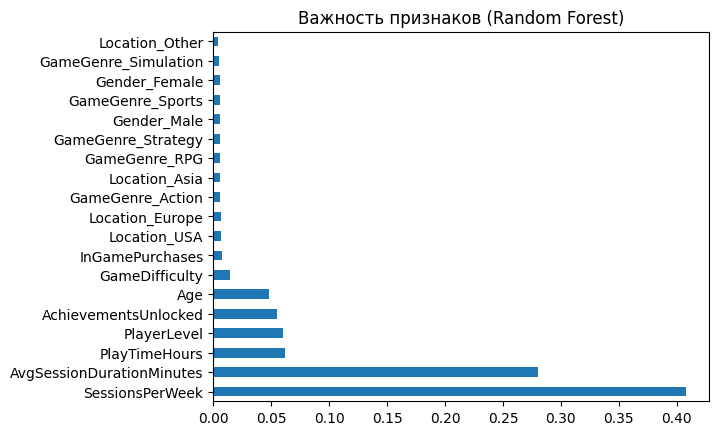

In [16]:
importances = pd.Series(rand_forest_class.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='barh')
plt.title("Важность признаков (Random Forest)")
plt.show()

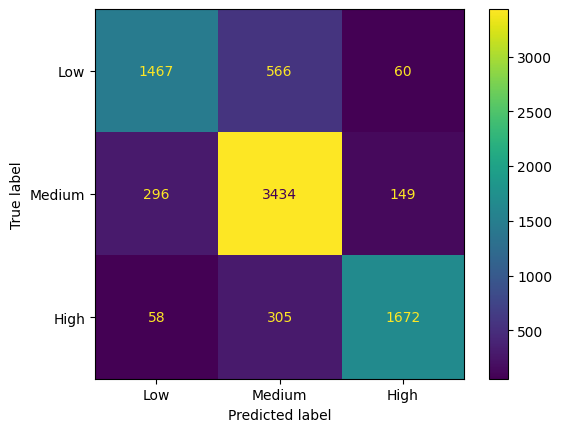

In [17]:
ConfusionMatrixDisplay.from_estimator(logistic_regressor, X_test_scaled, y_test, display_labels=['Low', 'Medium', 'High'])
plt.show()

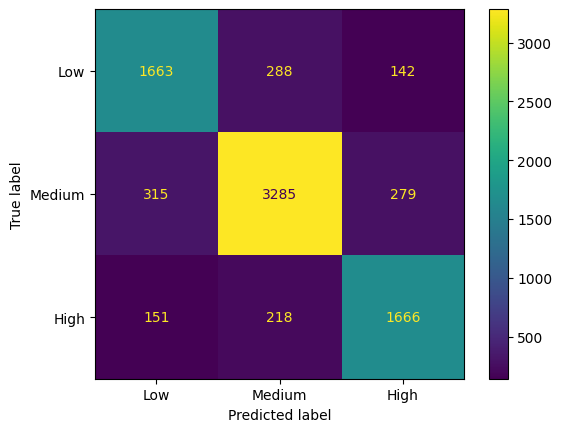

In [18]:
ConfusionMatrixDisplay.from_estimator(decision_tree, X_test, y_test, display_labels=['Low', 'Medium', 'High'])
plt.show()

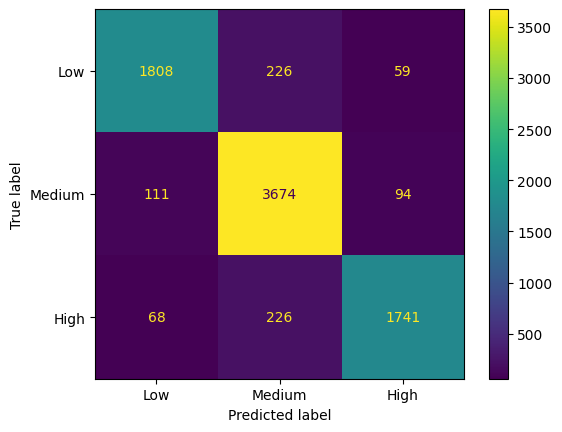

In [19]:
ConfusionMatrixDisplay.from_estimator(rand_forest_class, X_test, y_test, display_labels=['Low', 'Medium', 'High'])
plt.show()

*Вывод*

Наиболее удачной из линейных моделей классификации стала модель случайного леса со сбалансированными весами (процент попадания 89.9%)
Основные метрики, наиболее влияющие на заинтересованность пользователя: сессии в неделю (корреляция 0.6) и среднее время сессии (0.47), следом идут такие метрики, как окрытые достижения, уровень игрока (0.06 и 0.05) и другие, уже незначительно коррелирующие. Значительной зависимости от мастоположени или пола не наблюдается